# Análisis de series temporales
En el presente cuadernillo se halla la réplica del modelo de análisis de series temporales, hecho en `Python`, para el caso de análisis de este TFG. En este cuadernillo solo se realizará una réplica del modelo usado en el cuadernillo <a href="Análisis temporal en R.ipynb" target="_blank"><code>Análisis temporal en R.ipynb</code></a> y la comparación sintáctica para usarse como base para el uso del paquete `pyrcore` en la última parte del TFG. Se utiliza `auto_arima()`. El modelo no tiene por qué arrojar un resultado correcto, sino establecer el comportamiento habitual del modelo en Python.

**Caso de estudio**: Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

In [1]:
# Librerías
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from pmdarima import auto_arima
except:
    %pip install pmdarima
    from pmdarima.arima import auto_arima

## Importar datos

In [2]:
# Importar datos
gas=pd.read_excel("..\\datasets\\data_shale_gas_010822.xlsx", header=1)

# Previsualizar DataFrame
gas.head()

,Date,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK),Unnamed: 10
0,2000-01-01,0.133710,0.141004,0.000845,0.632070,0.000295,0.009290,0.013501,0.257174,0.687040,Units:
1,2000-02-01,0.139530,0.140833,0.000845,0.642394,0.000295,0.008526,0.013116,0.258500,0.694208,bcf per day
2,2000-03-01,0.150565,0.140300,0.000845,0.665302,0.000295,0.008626,0.012867,0.258599,0.704223,NaN
3,2000-04-01,0.159842,0.142965,0.000844,0.680048,0.000295,0.008810,0.013325,0.253798,0.689270,NaN
4,2000-05-01,0.163962,0.143643,0.000843,0.701509,0.000295,0.008716,0.012843,0.253023,0.724272,NaN


In [3]:
# Seleccionar la serie Barnett (TX)
gas=pd.Series(gas.iloc[:,1].tolist(),index=gas.Date.tolist())
gas.head()

2000-01-01    0.133710
2000-02-01    0.139530
2000-03-01    0.150565
2000-04-01    0.159842
2000-05-01    0.163962
dtype: float64

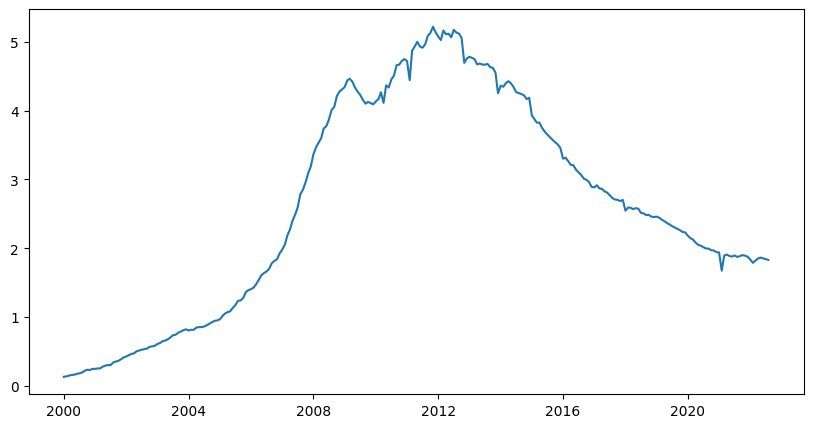

In [4]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(gas);

In [5]:
modelo=auto_arima(gas[:-5],m=12)
pred=modelo.predict(5)
pred

2022-04-01    1.795496
2022-05-01    1.792900
2022-06-01    1.774584
2022-07-01    1.771144
2022-08-01    1.753627
Freq: MS, dtype: float64

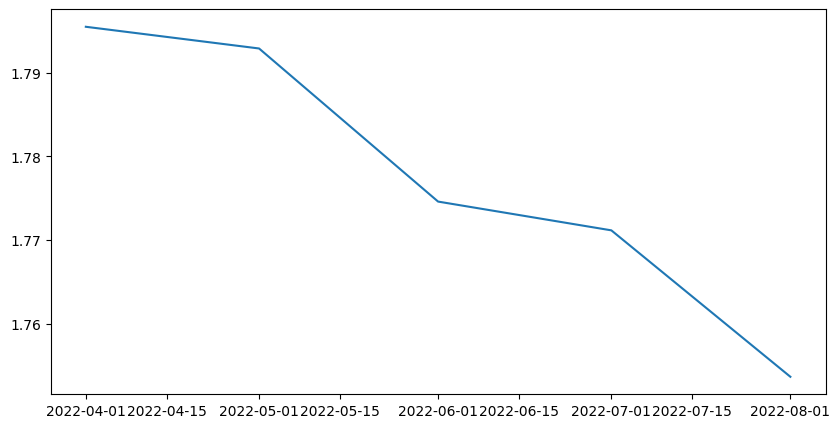

In [6]:
plt.figure(figsize=(10,5))
plt.plot(pred);

El modelo no funciona apropiadamente, pero ahora tenemos una idea de su comportamiento.